# Modul 4: Feature Selection, Dimensionality Reduction & Model Comparison

**Dataset**: Finance Fraud Detection (15.000 transaksi keuangan)
**Target**: `Is_Fraud` — 0 = Non-Fraud, 1 = Fraud

| Section | Topik |
|---------|-------|
| 1 | Feature Selection (EDA, Correlation-Based, Backward Elimination) |
| 2 | Dimensionality Reduction (PCA, t-SNE) |
| 3 | Model Comparison & Analysis (5 Pipeline) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
RANDOM_STATE = 42
DATASET_PATH = '/home/fatih/Documents/Projects/penggalian-data/modul4/dataset/finance_fraud_data.csv'

print('Libraries loaded successfully!')


Libraries loaded successfully!


In [2]:
df = pd.read_csv(DATASET_PATH)
print(f'Dataset shape: {df.shape}')
display(df.head(10))


Dataset shape: (15000, 12)


,Transaction_ID,Timestamp,Customer_ID,Amount,Merchant_Category,Distance_from_Home,Device_Type,IP_Risk_Score,Avg_Spending_Habit,Is_Weekend,Is_Night_Transaction,Is_Fraud
0,TRX-000001,2025-02-06 18:46:00,CUST-1727,1985.97,Luxury_Goods,0.0123,Android,0.89,94.75,0,0,1
1,TRX-000002,2025-03-25 09:19:00,CUST-1607,30.45,Food_Dining,0.0123,Android,0.85,26.00,0,0,0
2,TRX-000003,2025-02-17 17:05:00,CUST-1596,10.08,Transport,0.0123,Web_Browser,0.80,103.97,0,0,0
3,TRX-000004,2025-01-13 08:26:00,CUST-1980,8.20,Food_Dining,0.0123,Android,0.42,92.27,0,0,0
4,TRX-000005,2025-03-16 08:38:00,CUST-1235,181.07,Electronics,0.0123,Android,0.94,144.05,1,0,0
5,TRX-000006,2025-03-12 13:32:00,CUST-1293,19.98,Online_Services,0.0123,Android,0.41,87.35,0,0,0
6,TRX-000007,2025-03-31 04:55:00,CUST-1664,57.35,Groceries,0.0123,iOS,0.96,109.95,0,1,1
7,TRX-000008,2025-03-28 07:29:00,CUST-1927,9.21,Transport,0.0123,Android,0.06,98.74,0,0,0
8,TRX-000009,2025-03-20 04:07:00,CUST-1736,94.45,Groceries,0.0123,Android,0.59,144.82,0,1,0
9,TRX-000010,2025-02-06 20:25:00,CUST-1441,27.19,Transport,0.0123,iOS,0.13,128.07,0,0,0


---
# Section 1: Feature Selection

## 1.1 Exploratory Data Analysis (EDA)


In [3]:
print('=' * 65)
print('INFORMASI DATASET')
print('=' * 65)
print(f'  Jumlah baris  : {df.shape[0]:,}')
print(f'  Jumlah kolom  : {df.shape[1]}')

print()
print('Tipe data per kolom:')
display(df.dtypes.rename('Dtype').to_frame())

print()
print('Missing values per kolom:')
missing = df.isnull().sum().rename('Missing').to_frame()
missing['%'] = (missing['Missing'] / len(df) * 100).round(2)
display(missing)

print()
print('Statistik Deskriptif:')
display(df.describe(include='all').T)

print()
print('Distribusi Target (Is_Fraud):')
vc = df['Is_Fraud'].value_counts()
print(f'  Non-Fraud (0) : {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'  Fraud (1)     : {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')


INFORMASI DATASET
  Jumlah baris  : 15,000
  Jumlah kolom  : 12

Tipe data per kolom:


,Dtype
Transaction_ID,str
Timestamp,str
Customer_ID,str
Amount,float64
Merchant_Category,str
Distance_from_Home,float64
Device_Type,str
IP_Risk_Score,float64
Avg_Spending_Habit,float64
Is_Weekend,int64



Missing values per kolom:


,Missing,%
Transaction_ID,0,0.0
Timestamp,0,0.0
Customer_ID,0,0.0
Amount,0,0.0
Merchant_Category,0,0.0
Distance_from_Home,0,0.0
Device_Type,0,0.0
IP_Risk_Score,0,0.0
Avg_Spending_Habit,0,0.0
Is_Weekend,0,0.0



Statistik Deskriptif:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,15000,15000,TRX-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,15000,14122,2025-03-21 08:52:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,15000,1000,CUST-1664,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount,15000.0,NaN,NaN,NaN,197.627147,556.909653,2.58,22.1675,38.12,69.905,7987.24
Merchant_Category,15000,6,Groceries,4532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance_from_Home,15000.0,NaN,NaN,NaN,0.25852,1.058511,0.0123,0.0123,0.0123,0.0123,4.8088
Device_Type,15000,3,Android,6788,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IP_Risk_Score,15000.0,NaN,NaN,NaN,0.5019,0.290001,0.0,0.25,0.5,0.75,1.0
Avg_Spending_Habit,15000.0,NaN,NaN,NaN,99.813583,29.930782,-36.68,79.7,100.05,120.05,200.55
Is_Weekend,15000.0,NaN,NaN,NaN,0.286467,0.452125,0.0,0.0,0.0,1.0,1.0



Distribusi Target (Is_Fraud):
  Non-Fraud (0) : 13,165  (87.8%)
  Fraud (1)     : 1,835  (12.2%)


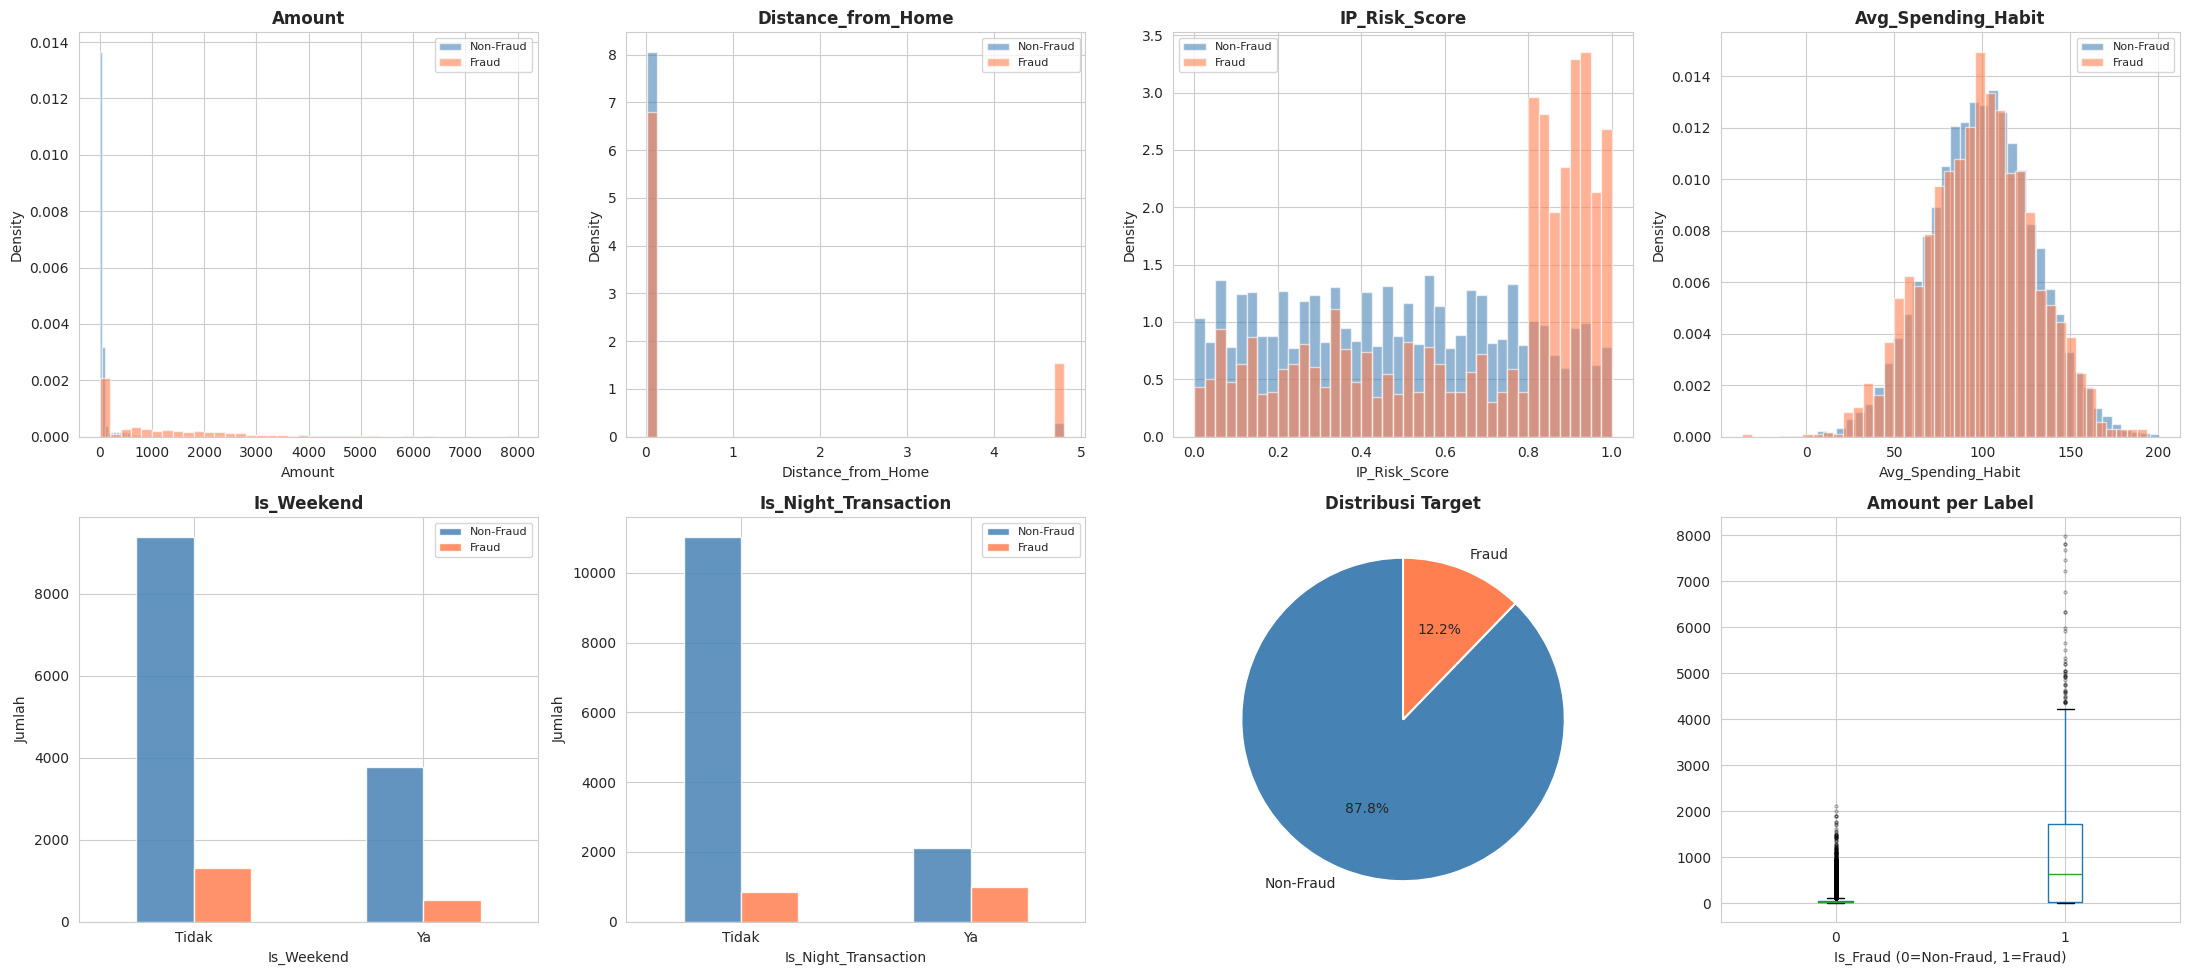

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('EDA – Distribusi Fitur Numerik & Biner', fontsize=15, fontweight='bold', y=1.01)

num_cols = ['Amount', 'Distance_from_Home', 'IP_Risk_Score', 'Avg_Spending_Habit']
palette  = ['steelblue', 'coral']

# Row 0: histograms per class
for i, col in enumerate(num_cols):
    ax = axes[0][i]
    for label, color, name in [(0, 'steelblue', 'Non-Fraud'), (1, 'coral', 'Fraud')]:
        df[df['Is_Fraud'] == label][col].plot.hist(
            ax=ax, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# Row 1: binary cols
bin_cols = ['Is_Weekend', 'Is_Night_Transaction']
for i, col in enumerate(bin_cols):
    ax = axes[1][i]
    counts = df.groupby([col, 'Is_Fraud']).size().unstack(fill_value=0)
    counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], alpha=0.85, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xticklabels(['Tidak', 'Ya'], rotation=0)
    ax.set_ylabel('Jumlah')
    ax.legend(['Non-Fraud', 'Fraud'], fontsize=8)

# Fraud pie
ax = axes[1][2]
vc = df['Is_Fraud'].value_counts()
ax.pie(vc.values, labels=['Non-Fraud', 'Fraud'], colors=['steelblue', 'coral'],
       autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Distribusi Target', fontweight='bold')

# Amount boxplot
ax = axes[1][3]
df.boxplot(column='Amount', by='Is_Fraud', ax=ax,
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Amount per Label', fontweight='bold')
ax.set_xlabel('Is_Fraud (0=Non-Fraud, 1=Fraud)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_numerical.png', bbox_inches='tight', dpi=120)
plt.show()


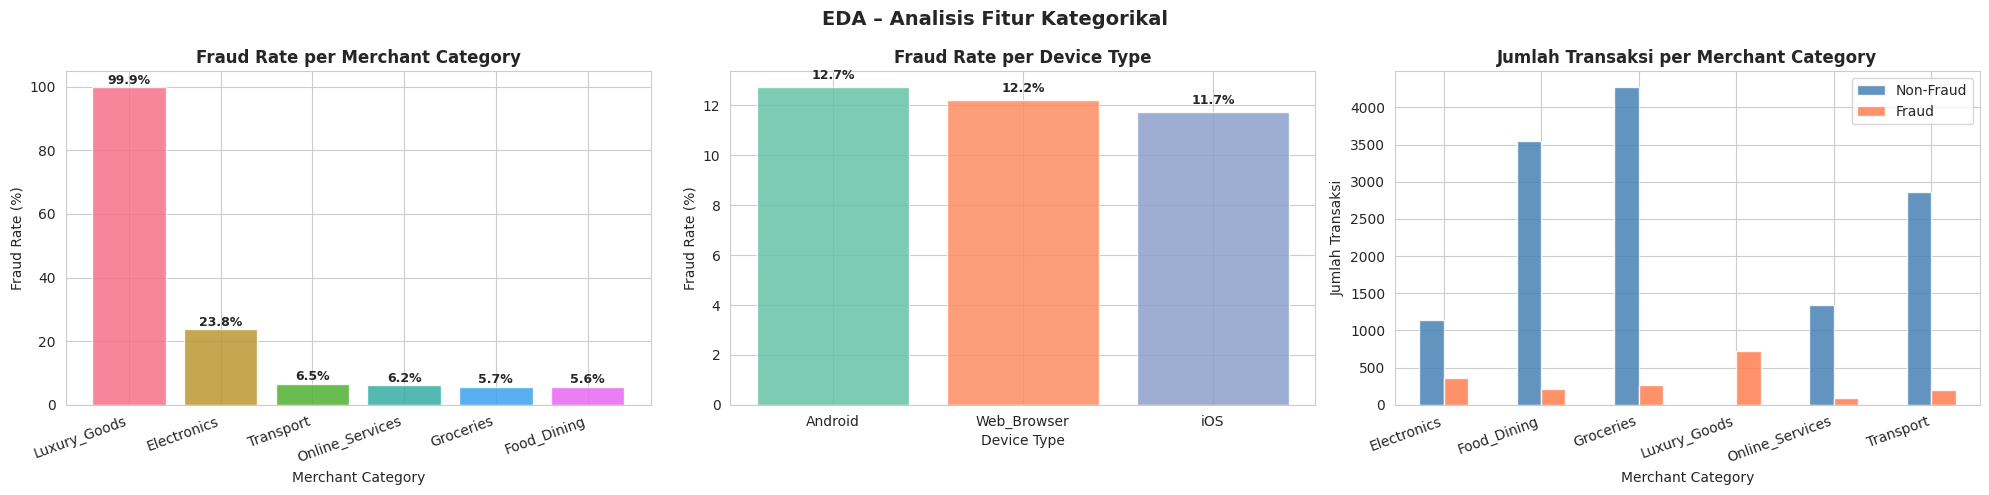

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('EDA – Analisis Fitur Kategorikal', fontsize=14, fontweight='bold')

# Merchant Category fraud rate
cat_fraud = df.groupby('Merchant_Category')['Is_Fraud'].mean().sort_values(ascending=False)
ax = axes[0]
bars = ax.bar(cat_fraud.index, cat_fraud.values * 100,
              color=sns.color_palette('husl', len(cat_fraud)), alpha=0.85, edgecolor='white')
ax.set_title('Fraud Rate per Merchant Category', fontweight='bold')
ax.set_xlabel('Merchant Category')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticklabels(cat_fraud.index, rotation=20, ha='right')
for bar, val in zip(bars, cat_fraud.values * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Device Type fraud rate
dev_fraud = df.groupby('Device_Type')['Is_Fraud'].mean().sort_values(ascending=False)
ax = axes[1]
bars = ax.bar(dev_fraud.index, dev_fraud.values * 100,
              color=sns.color_palette('Set2', len(dev_fraud)), alpha=0.85, edgecolor='white')
ax.set_title('Fraud Rate per Device Type', fontweight='bold')
ax.set_xlabel('Device Type')
ax.set_ylabel('Fraud Rate (%)')
for bar, val in zip(bars, dev_fraud.values * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Transaction count per category
ax = axes[2]
cat_counts = df.groupby(['Merchant_Category', 'Is_Fraud']).size().unstack(fill_value=0)
cat_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], alpha=0.85, edgecolor='white')
ax.set_title('Jumlah Transaksi per Merchant Category', fontweight='bold')
ax.set_xlabel('Merchant Category')
ax.set_ylabel('Jumlah Transaksi')
ax.set_xticklabels(cat_counts.index, rotation=20, ha='right')
ax.legend(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.savefig('eda_categorical.png', bbox_inches='tight', dpi=120)
plt.show()


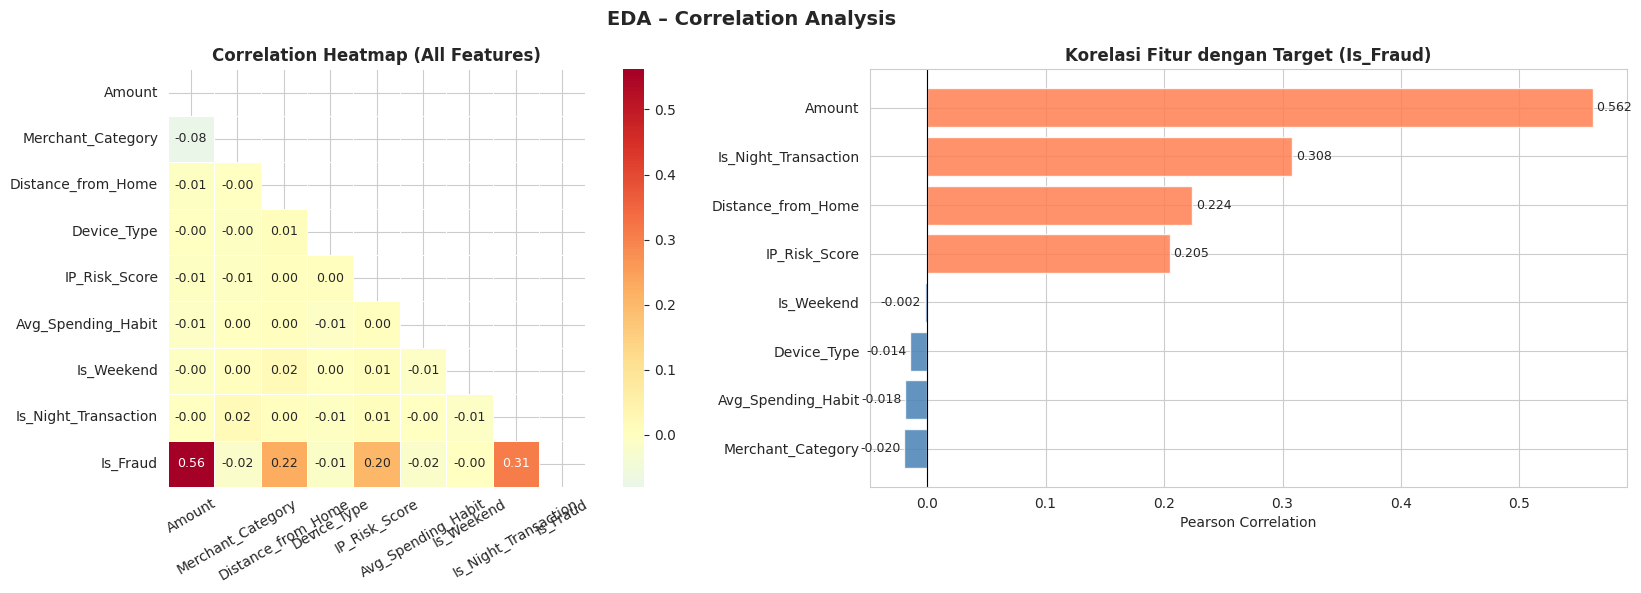

In [6]:
# Encode for correlation computation
df_enc = df.copy()
le = LabelEncoder()
df_enc['Merchant_Category'] = le.fit_transform(df_enc['Merchant_Category'])
df_enc['Device_Type']       = le.fit_transform(df_enc['Device_Type'])
df_enc = df_enc.drop(columns=['Transaction_ID', 'Timestamp', 'Customer_ID'])

corr = df_enc.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('EDA – Correlation Analysis', fontsize=14, fontweight='bold')

# Full heatmap (lower triangle)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=axes[0], linewidths=0.5, square=True, annot_kws={'size': 9})
axes[0].set_title('Correlation Heatmap (All Features)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Correlation with target
corr_target = corr['Is_Fraud'].drop('Is_Fraud').sort_values()
colors = ['coral' if v > 0 else 'steelblue' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors, alpha=0.85, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Korelasi Fitur dengan Target (Is_Fraud)', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')
for i, (val, name) in enumerate(zip(corr_target.values, corr_target.index)):
    offset = 0.003 if val >= 0 else -0.003
    ha = 'left' if val >= 0 else 'right'
    axes[1].text(val + offset, i, f'{val:.3f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig('eda_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()


## 1.2 Preprocessing

Langkah-langkah:
1. Hapus kolom ID: `Transaction_ID`, `Timestamp`, `Customer_ID`
2. Encode fitur kategorikal: `Merchant_Category`, `Device_Type` → `LabelEncoder`
3. Train-test split (80/20, stratified)


In [7]:
# Drop ID columns
drop_cols    = ['Transaction_ID', 'Timestamp', 'Customer_ID']
df_proc      = df.drop(columns=drop_cols).copy()

# Encode categoricals
le_merchant  = LabelEncoder()
le_device    = LabelEncoder()
df_proc['Merchant_Category'] = le_merchant.fit_transform(df_proc['Merchant_Category'])
df_proc['Device_Type']       = le_device.fit_transform(df_proc['Device_Type'])

# Features & target
feature_cols = [c for c in df_proc.columns if c != 'Is_Fraud']
X = df_proc[feature_cols]
y = df_proc['Is_Fraud']

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Feature columns:', feature_cols)
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Fraud rate train: {y_train.mean():.3f}  |  Fraud rate test: {y_test.mean():.3f}')
display(X.head())


Feature columns: ['Amount', 'Merchant_Category', 'Distance_from_Home', 'Device_Type', 'IP_Risk_Score', 'Avg_Spending_Habit', 'Is_Weekend', 'Is_Night_Transaction']
X_train: (12000, 8)  |  X_test: (3000, 8)
Fraud rate train: 0.122  |  Fraud rate test: 0.122


,Amount,Merchant_Category,Distance_from_Home,Device_Type,IP_Risk_Score,Avg_Spending_Habit,Is_Weekend,Is_Night_Transaction
0,1985.97,3,0.0123,0,0.89,94.75,0,0
1,30.45,1,0.0123,0,0.85,26.00,0,0
2,10.08,5,0.0123,1,0.80,103.97,0,0
3,8.20,1,0.0123,0,0.42,92.27,0,0
4,181.07,0,0.0123,0,0.94,144.05,1,0


## 1.3 Feature Selection – Metode 1: Correlation-Based

**Langkah**:
1. Hitung korelasi Pearson setiap fitur dengan target `Is_Fraud`
2. Pertahankan fitur dengan |korelasi| ≥ threshold (0.05)
3. Hapus fitur yang saling berkorelasi tinggi (> 0.85) untuk mengurangi redundansi


In [8]:
CORR_TARGET_THRESHOLD  = 0.05   # min |corr| dengan target
CORR_INTER_THRESHOLD   = 0.85   # max |corr| antar fitur

# Step 1: korelasi dengan target
train_full      = X_train.assign(Is_Fraud=y_train)
corr_with_target = train_full.corr()['Is_Fraud'].drop('Is_Fraud').abs().sort_values(ascending=False)

print('Korelasi |Pearson| dengan target Is_Fraud:')
display(corr_with_target.rename('|Correlation|').to_frame())

# Step 2: filter berdasarkan threshold
corr_selected = corr_with_target[corr_with_target >= CORR_TARGET_THRESHOLD].index.tolist()
print(f'\nFitur dengan |corr| >= {CORR_TARGET_THRESHOLD}: {corr_selected}')

# Step 3: hapus fitur redundan (inter-feature correlation)
inter_corr   = X_train[corr_selected].corr().abs()
upper_tri    = inter_corr.where(np.triu(np.ones(inter_corr.shape), k=1).astype(bool))
redundant    = [c for c in upper_tri.columns if any(upper_tri[c] > CORR_INTER_THRESHOLD)]

if redundant:
    print(f'Fitur redundan dihapus (inter-corr > {CORR_INTER_THRESHOLD}): {redundant}')
    corr_selected = [f for f in corr_selected if f not in redundant]
else:
    print(f'Tidak ada fitur redundan (threshold inter-corr = {CORR_INTER_THRESHOLD})')

features_corr = corr_selected
print(f'\n✓ Fitur Correlation-Based terpilih ({len(features_corr)}): {features_corr}')


Korelasi |Pearson| dengan target Is_Fraud:


,|Correlation|
Amount,0.563387
Is_Night_Transaction,0.306402
Distance_from_Home,0.217095
IP_Risk_Score,0.207471
Merchant_Category,0.018486
Avg_Spending_Habit,0.014913
Device_Type,0.010726
Is_Weekend,0.005929



Fitur dengan |corr| >= 0.05: ['Amount', 'Is_Night_Transaction', 'Distance_from_Home', 'IP_Risk_Score']
Tidak ada fitur redundan (threshold inter-corr = 0.85)

✓ Fitur Correlation-Based terpilih (4): ['Amount', 'Is_Night_Transaction', 'Distance_from_Home', 'IP_Risk_Score']


## 1.4 Feature Selection – Metode 2: Backward Elimination

**Langkah**:
1. Mulai dengan semua fitur
2. Fit Logistic Regression menggunakan `statsmodels` (Wald test p-value)
3. Hapus fitur dengan p-value tertinggi jika > threshold (0.05)
4. Ulangi hingga semua fitur signifikan


In [9]:
# Scale for logistic regression stability
scaler_be       = StandardScaler()
X_train_scaled  = scaler_be.fit_transform(X_train)
X_train_be      = pd.DataFrame(X_train_scaled, columns=feature_cols)
y_train_be      = y_train.reset_index(drop=True)

def backward_elimination(X_df, y_series, threshold=0.05, verbose=True):
    features  = list(X_df.columns)
    iteration = 0
    log       = []

    while True:
        X_const = sm.add_constant(X_df[features])
        model   = sm.Logit(y_series, X_const).fit(disp=0, maxiter=200)
        pvalues = model.pvalues.drop('const', errors='ignore')
        pvalues.index = features

        max_pval = pvalues.max()
        max_feat = pvalues.idxmax()

        log.append({
            'Iterasi'        : iteration,
            'Jumlah Fitur'   : len(features),
            'Fitur Dihapus'  : max_feat if max_pval > threshold else '-',
            'P-value Tertinggi': round(max_pval, 6),
        })

        if verbose:
            print(f'Iter {iteration:2d} | {len(features)} fitur | '
                  f'max p-val: {max_pval:.5f} ({max_feat})', end='')

        if max_pval > threshold:
            features.remove(max_feat)
            if verbose:
                print(f'  → HAPUS')
            iteration += 1
        else:
            if verbose:
                print(f'  → SELESAI (semua p < {threshold})')
            break

        if len(features) == 0:
            break

    return features, pd.DataFrame(log)

print('=' * 65)
print('BACKWARD ELIMINATION  (threshold p-value = 0.05)')
print('=' * 65)
features_be, be_log = backward_elimination(X_train_be, y_train_be, threshold=0.05)

print(f'\n✓ Fitur Backward Elimination terpilih ({len(features_be)}): {features_be}')
print()
display(be_log)


BACKWARD ELIMINATION  (threshold p-value = 0.05)
Iter  0 | 8 fitur | max p-val: 0.90212 (Is_Weekend)  → HAPUS
Iter  1 | 7 fitur | max p-val: 0.48091 (Device_Type)  → HAPUS
Iter  2 | 6 fitur | max p-val: 0.00076 (Avg_Spending_Habit)  → SELESAI (semua p < 0.05)

✓ Fitur Backward Elimination terpilih (6): ['Amount', 'Merchant_Category', 'Distance_from_Home', 'IP_Risk_Score', 'Avg_Spending_Habit', 'Is_Night_Transaction']



,Iterasi,Jumlah Fitur,Fitur Dihapus,P-value Tertinggi
0,0,8,Is_Weekend,0.902115
1,1,7,Device_Type,0.480914
2,2,6,-,0.000760


## 1.5 Perbandingan Feature Selection Methods


In [10]:
def evaluate_features(feat_list, label):
    sc  = StandardScaler()
    Xtr = sc.fit_transform(X_train[feat_list])
    Xte = sc.transform(X_test[feat_list])
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    return {
        'Method'   : label,
        'N Fitur'  : len(feat_list),
        'Fitur'    : ', '.join(feat_list),
        'Accuracy' : round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall'   : round(recall_score(y_test, pred), 4),
        'F1-Score' : round(f1_score(y_test, pred), 4),
    }

res_corr = evaluate_features(features_corr, 'Correlation-Based')
res_be   = evaluate_features(features_be,   'Backward Elimination')

df_fs_compare = pd.DataFrame([res_corr, res_be]).set_index('Method')

print('=' * 65)
print('TABEL PERBANDINGAN FEATURE SELECTION')
print('=' * 65)
display(df_fs_compare.style.format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
    'Recall'  : '{:.4f}', 'F1-Score' : '{:.4f}',
}).background_gradient(subset=['Accuracy','Precision','Recall','F1-Score'],
                        cmap='RdYlGn', axis=0))

# Best method
best_fs      = res_corr['Method'] if res_corr['F1-Score'] >= res_be['F1-Score'] else res_be['Method']
features_best = features_corr if best_fs == 'Correlation-Based' else features_be
print(f'\n★  Metode terbaik: {best_fs}  (F1={max(res_corr["F1-Score"], res_be["F1-Score"]):.4f})')
print(f'   Fitur terpilih : {features_best}')


TABEL PERBANDINGAN FEATURE SELECTION


,N Fitur,Fitur,Accuracy,Precision,Recall,F1-Score
Method,,,,,,
Correlation-Based,4,"Amount, Is_Night_Transaction, Distance_from_Home, IP_Risk_Score",0.9757,0.9200,0.8774,0.8982
Backward Elimination,6,"Amount, Merchant_Category, Distance_from_Home, IP_Risk_Score, Avg_Spending_Habit, Is_Night_Transaction",0.9750,0.9294,0.8610,0.8939



★  Metode terbaik: Correlation-Based  (F1=0.8982)
   Fitur terpilih : ['Amount', 'Is_Night_Transaction', 'Distance_from_Home', 'IP_Risk_Score']


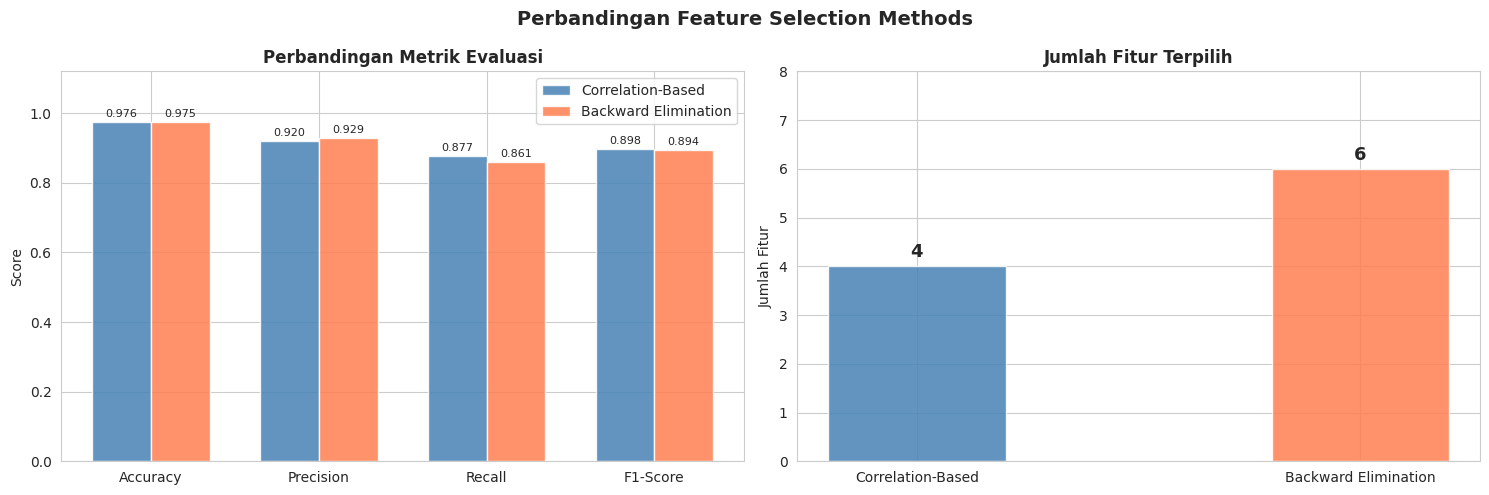

In [11]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_list))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Perbandingan Feature Selection Methods', fontsize=14, fontweight='bold')

# Bar chart – metrics
ax = axes[0]
b1 = ax.bar(x - w/2, [res_corr[m] for m in metrics_list], w,
            label='Correlation-Based', color='steelblue', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, [res_be[m]   for m in metrics_list], w,
            label='Backward Elimination', color='coral', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('Perbandingan Metrik Evaluasi', fontweight='bold')
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Feature count comparison
ax = axes[1]
methods = ['Correlation-Based', 'Backward Elimination']
counts  = [res_corr['N Fitur'], res_be['N Fitur']]
bars = ax.bar(methods, counts, color=['steelblue', 'coral'], alpha=0.85, width=0.4, edgecolor='white')
ax.set_ylabel('Jumlah Fitur')
ax.set_title('Jumlah Fitur Terpilih', fontweight='bold')
ax.set_ylim(0, max(counts) + 2)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(count), ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fs_comparison.png', bbox_inches='tight', dpi=120)
plt.show()


---
# Section 2: Dimensionality Reduction

## 2.1 Principal Component Analysis (PCA)


Jumlah komponen untuk 95% variance: 8

  PC 1:  13.54%  (kumulatif:  13.54%)
  PC 2:  12.83%  (kumulatif:  26.38%)
  PC 3:  12.62%  (kumulatif:  39.00%)
  PC 4:  12.58%  (kumulatif:  51.58%)
  PC 5:  12.47%  (kumulatif:  64.04%)
  PC 6:  12.42%  (kumulatif:  76.46%)
  PC 7:  12.09%  (kumulatif:  88.55%)
  PC 8:  11.45%  (kumulatif: 100.00%) ←


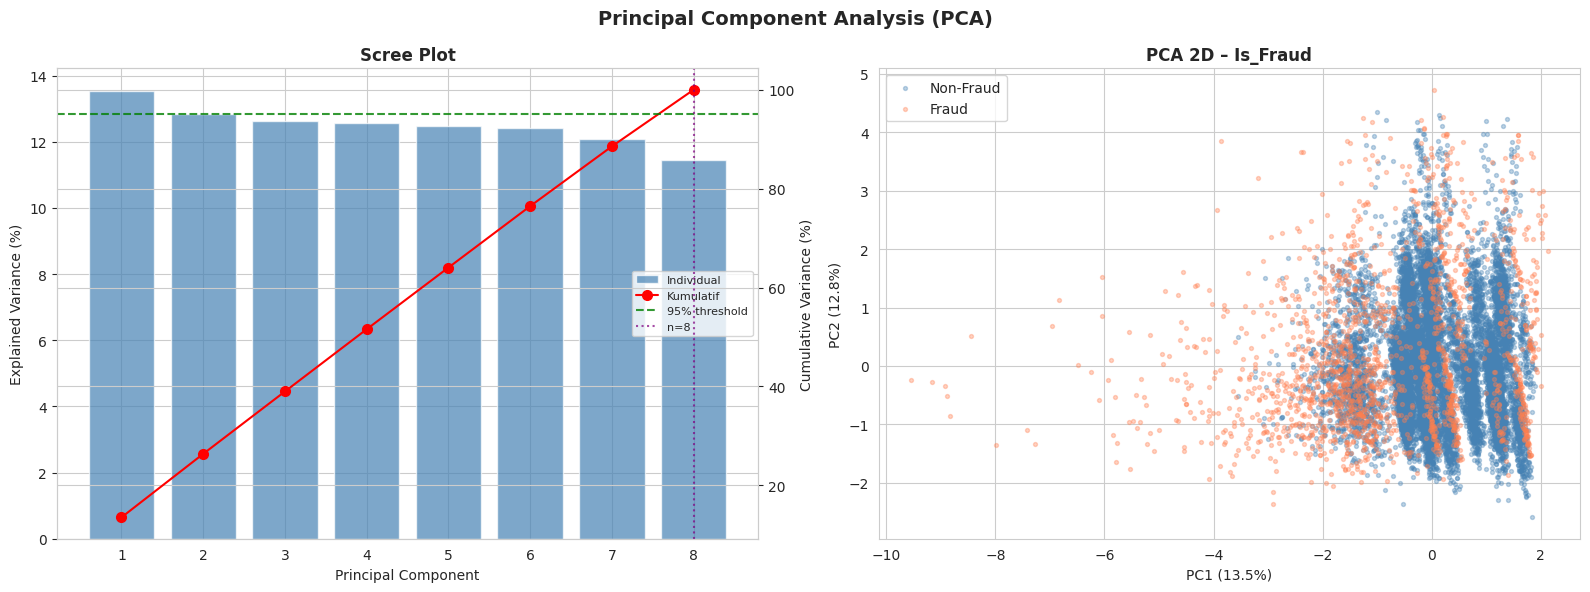

In [12]:
# Fit scaler & PCA on full dataset (for visualisasi)
scaler_pca   = StandardScaler()
X_all_scaled = scaler_pca.fit_transform(X)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_all_scaled)

exp_var  = pca_full.explained_variance_ratio_
cum_var  = np.cumsum(exp_var)
n95      = int(np.argmax(cum_var >= 0.95)) + 1

print(f'Jumlah komponen untuk 95% variance: {n95}')
print()
for i, (v, c) in enumerate(zip(exp_var, cum_var)):
    mark = ' ←' if i + 1 == n95 else ''
    print(f'  PC{i+1:2d}: {v*100:6.2f}%  (kumulatif: {c*100:6.2f}%){mark}')

# 2D untuk visualisasi
X_pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_all_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Principal Component Analysis (PCA)', fontsize=14, fontweight='bold')

# Scree plot
ax  = axes[0]
ax2 = ax.twinx()
ax.bar(range(1, len(exp_var)+1), exp_var*100, alpha=0.7, color='steelblue', label='Individual')
ax2.plot(range(1, len(exp_var)+1), cum_var*100, 'ro-', markersize=7, label='Kumulatif')
ax2.axhline(y=95, color='green', linestyle='--', alpha=0.8, label='95% threshold')
ax2.axvline(x=n95, color='purple', linestyle=':', alpha=0.7, label=f'n={n95}')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax2.set_ylabel('Cumulative Variance (%)')
ax.set_title('Scree Plot', fontweight='bold')
lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lbl1 + lbl2, loc='center right', fontsize=8)

# 2D scatter
ax = axes[1]
for lbl, color, name in [(0,'steelblue','Non-Fraud'),(1,'coral','Fraud')]:
    mask = (y == lbl).values
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=color, alpha=0.35, s=8, label=name)
ax.set_xlabel(f'PC1 ({exp_var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({exp_var[1]*100:.1f}%)')
ax.set_title('PCA 2D – Is_Fraud', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('pca_analysis.png', bbox_inches='tight', dpi=120)
plt.show()


## 2.2 t-Distributed Stochastic Neighbor Embedding (t-SNE)


Menjalankan t-SNE pada 3000 sampel (perplexity=30, max_iter=1000)...


t-SNE selesai!


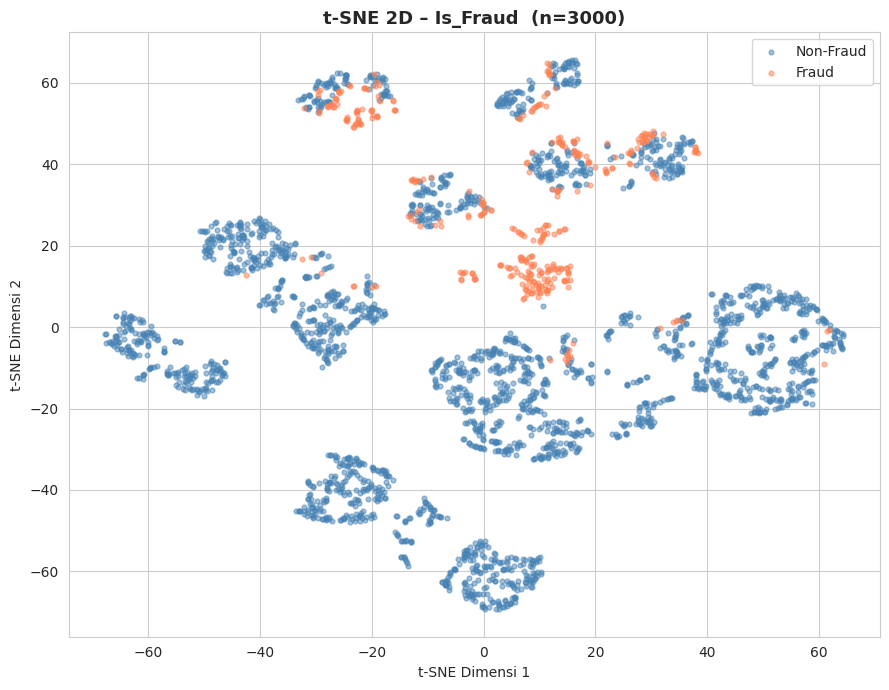

In [13]:
N_SAMPLE = 3000  # t-SNE lambat pada data besar

rng        = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X), N_SAMPLE, replace=False)
X_sample   = X_all_scaled[sample_idx]
y_sample   = y.values[sample_idx]

print(f'Menjalankan t-SNE pada {N_SAMPLE} sampel (perplexity=30, max_iter=1000)...')
tsne   = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_sample)
print('t-SNE selesai!')

fig, ax = plt.subplots(figsize=(9, 7))
for lbl, color, name in [(0,'steelblue','Non-Fraud'),(1,'coral','Fraud')]:
    mask = y_sample == lbl
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, alpha=0.5, s=12, label=name)
ax.set_xlabel('t-SNE Dimensi 1')
ax.set_ylabel('t-SNE Dimensi 2')
ax.set_title(f't-SNE 2D – Is_Fraud  (n={N_SAMPLE})', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('tsne_analysis.png', bbox_inches='tight', dpi=120)
plt.show()


## 2.3 Perbandingan PCA vs t-SNE


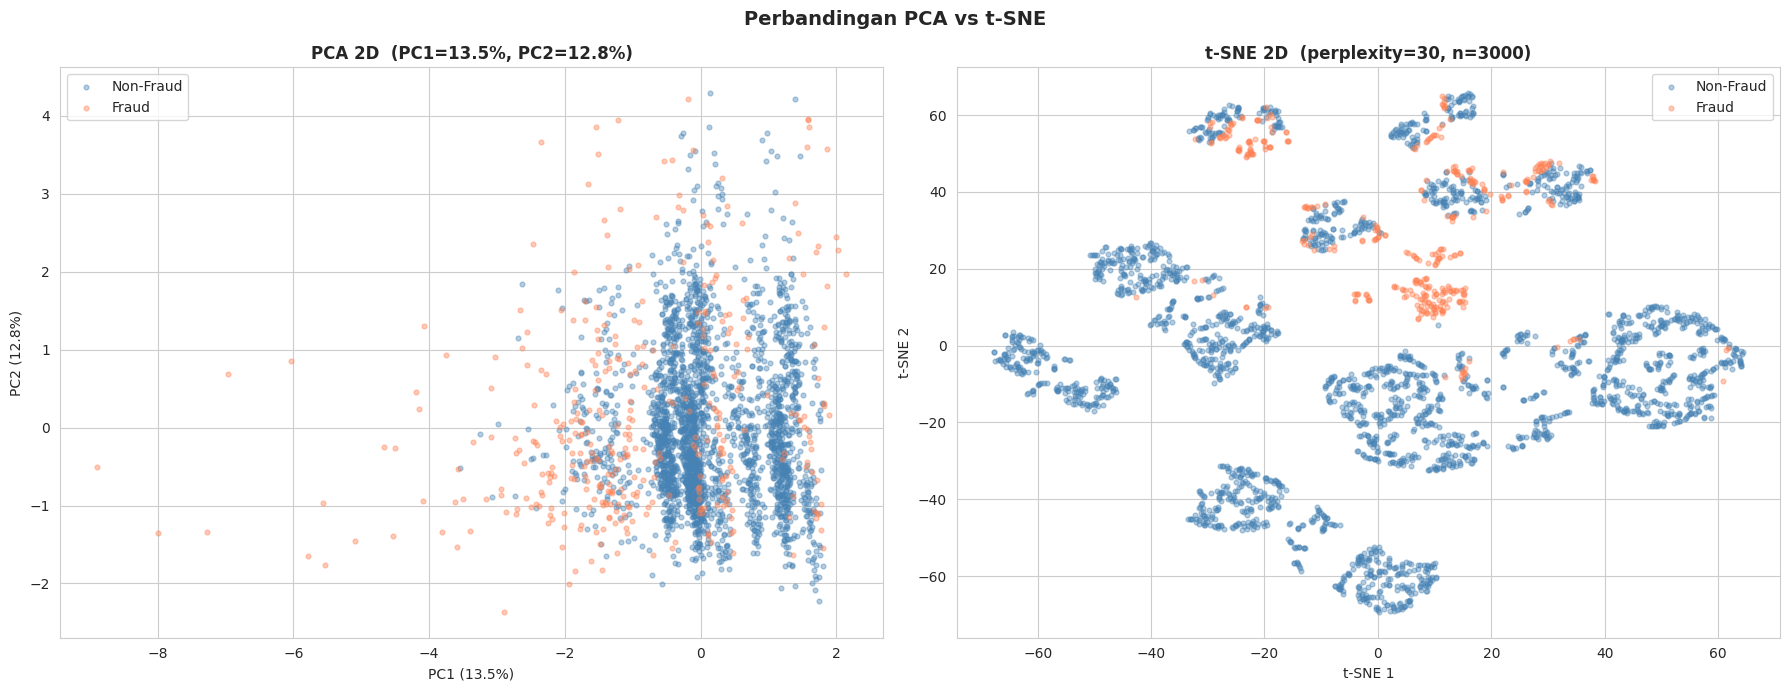

Aspek,PCA,t-SNE
Tipe Metode,Linear,Non-Linear
Kompleksitas,O(n·p²),O(n²)
Skalabilitas Data Besar,Baik,Buruk (perlu sampling)
Preservasi Struktur Global,Baik,Buruk
Preservasi Struktur Lokal,Sedang,Sangat Baik
Interpretabilitas,Tinggi (loadings),Rendah
Output Terbaik Untuk,Feature Engineering & Reduksi Dimensi,Visualisasi Eksplorasi


In [14]:
# Side-by-side comparison (same sample)
X_pca_sample = X_pca_2d[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Perbandingan PCA vs t-SNE', fontsize=14, fontweight='bold')

titles = [f'PCA 2D  (PC1={exp_var[0]*100:.1f}%, PC2={exp_var[1]*100:.1f}%)',
          f't-SNE 2D  (perplexity=30, n={N_SAMPLE})']
data   = [X_pca_sample, X_tsne]
xlabels = [f'PC1 ({exp_var[0]*100:.1f}%)', 't-SNE 1']
ylabels = [f'PC2 ({exp_var[1]*100:.1f}%)', 't-SNE 2']

for ax, Xd, title, xl, yl in zip(axes, data, titles, xlabels, ylabels):
    for lbl, color, name in [(0,'steelblue','Non-Fraud'),(1,'coral','Fraud')]:
        mask = y_sample == lbl
        ax.scatter(Xd[mask, 0], Xd[mask, 1], c=color, alpha=0.4, s=12, label=name)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.legend()

plt.tight_layout()
plt.savefig('pca_vs_tsne.png', bbox_inches='tight', dpi=120)
plt.show()

# Comparison table
df_dr_compare = pd.DataFrame({
    'Aspek'                    : ['Tipe Metode','Kompleksitas','Skalabilitas Data Besar',
                                   'Preservasi Struktur Global','Preservasi Struktur Lokal',
                                   'Interpretabilitas','Output Terbaik Untuk'],
    'PCA'                      : ['Linear','O(n·p²)','Baik',
                                   'Baik','Sedang',
                                   'Tinggi (loadings)','Feature Engineering & Reduksi Dimensi'],
    't-SNE'                    : ['Non-Linear','O(n²)','Buruk (perlu sampling)',
                                   'Buruk','Sangat Baik',
                                   'Rendah','Visualisasi Eksplorasi'],
})
print()
display(df_dr_compare.style.set_properties(**{'text-align':'left'}).hide(axis='index'))


---
# Section 3: Model Comparison & Analysis

## 3.1 Definisi 5 Pipeline

| # | Pipeline | Input Fitur | Transformasi | Classifier |
|---|----------|-------------|--------------|------------|
| 1 | Baseline | Semua fitur | StandardScaler | LogisticRegression |
| 2 | Best FS  | Fitur terpilih (FS terbaik) | StandardScaler | LogisticRegression |
| 3 | PCA      | Semua fitur | StandardScaler → PCA | LogisticRegression |
| 4 | LDA      | Semua fitur | StandardScaler | LinearDiscriminantAnalysis |
| 5 | Combination | Fitur terpilih | StandardScaler → PCA | LogisticRegression |


In [15]:
# Reset indices for clean pipeline input
X_tr = X_train.reset_index(drop=True)
X_te = X_test.reset_index(drop=True)
y_tr = y_train.reset_index(drop=True)
y_te = y_test.reset_index(drop=True)

n_combo = min(n95, len(features_best))

pipelines_def = [
    ('Baseline (All Features)',
     X_tr, X_te,
     Pipeline([('sc', StandardScaler()),
               ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])),

    (f'Best FS ({best_fs})',
     X_tr[features_best], X_te[features_best],
     Pipeline([('sc', StandardScaler()),
               ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])),

    ('PCA',
     X_tr, X_te,
     Pipeline([('sc', StandardScaler()),
               ('pca', PCA(n_components=n95, random_state=RANDOM_STATE)),
               ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])),

    ('LDA',
     X_tr, X_te,
     Pipeline([('sc', StandardScaler()),
               ('clf', LinearDiscriminantAnalysis())])),

    ('Combination (FS + PCA)',
     X_tr[features_best], X_te[features_best],
     Pipeline([('sc', StandardScaler()),
               ('pca', PCA(n_components=n_combo, random_state=RANDOM_STATE)),
               ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])),
]

results      = {}
conf_matrices = {}

for name, Xtr_p, Xte_p, pipe in pipelines_def:
    pipe.fit(Xtr_p, y_tr)
    y_pred = pipe.predict(Xte_p)
    results[name] = {
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall'   : round(recall_score(y_te, y_pred), 4),
        'F1-Score' : round(f1_score(y_te, y_pred), 4),
    }
    conf_matrices[name] = confusion_matrix(y_te, y_pred)
    print(f'✓ {name:35s}  F1={results[name]["F1-Score"]:.4f}')

df_results = pd.DataFrame(results).T[['Accuracy','Precision','Recall','F1-Score']]

print()
print('=' * 70)
print('HASIL EVALUASI SEMUA PIPELINE')
print('=' * 70)
display(df_results.style
    .format('{:.4f}')
    .background_gradient(cmap='RdYlGn', axis=0)
    .highlight_max(color='#90EE90'))


✓ Baseline (All Features)              F1=0.8955
✓ Best FS (Correlation-Based)          F1=0.8982
✓ PCA                                  F1=0.8955
✓ LDA                                  F1=0.6990
✓ Combination (FS + PCA)               F1=0.8982

HASIL EVALUASI SEMUA PIPELINE


,Accuracy,Precision,Recall,F1-Score
Baseline (All Features),0.9753,0.9296,0.8638,0.8955
Best FS (Correlation-Based),0.9757,0.9200,0.8774,0.8982
PCA,0.9753,0.9296,0.8638,0.8955
LDA,0.9420,0.9573,0.5504,0.6990
Combination (FS + PCA),0.9757,0.9200,0.8774,0.8982


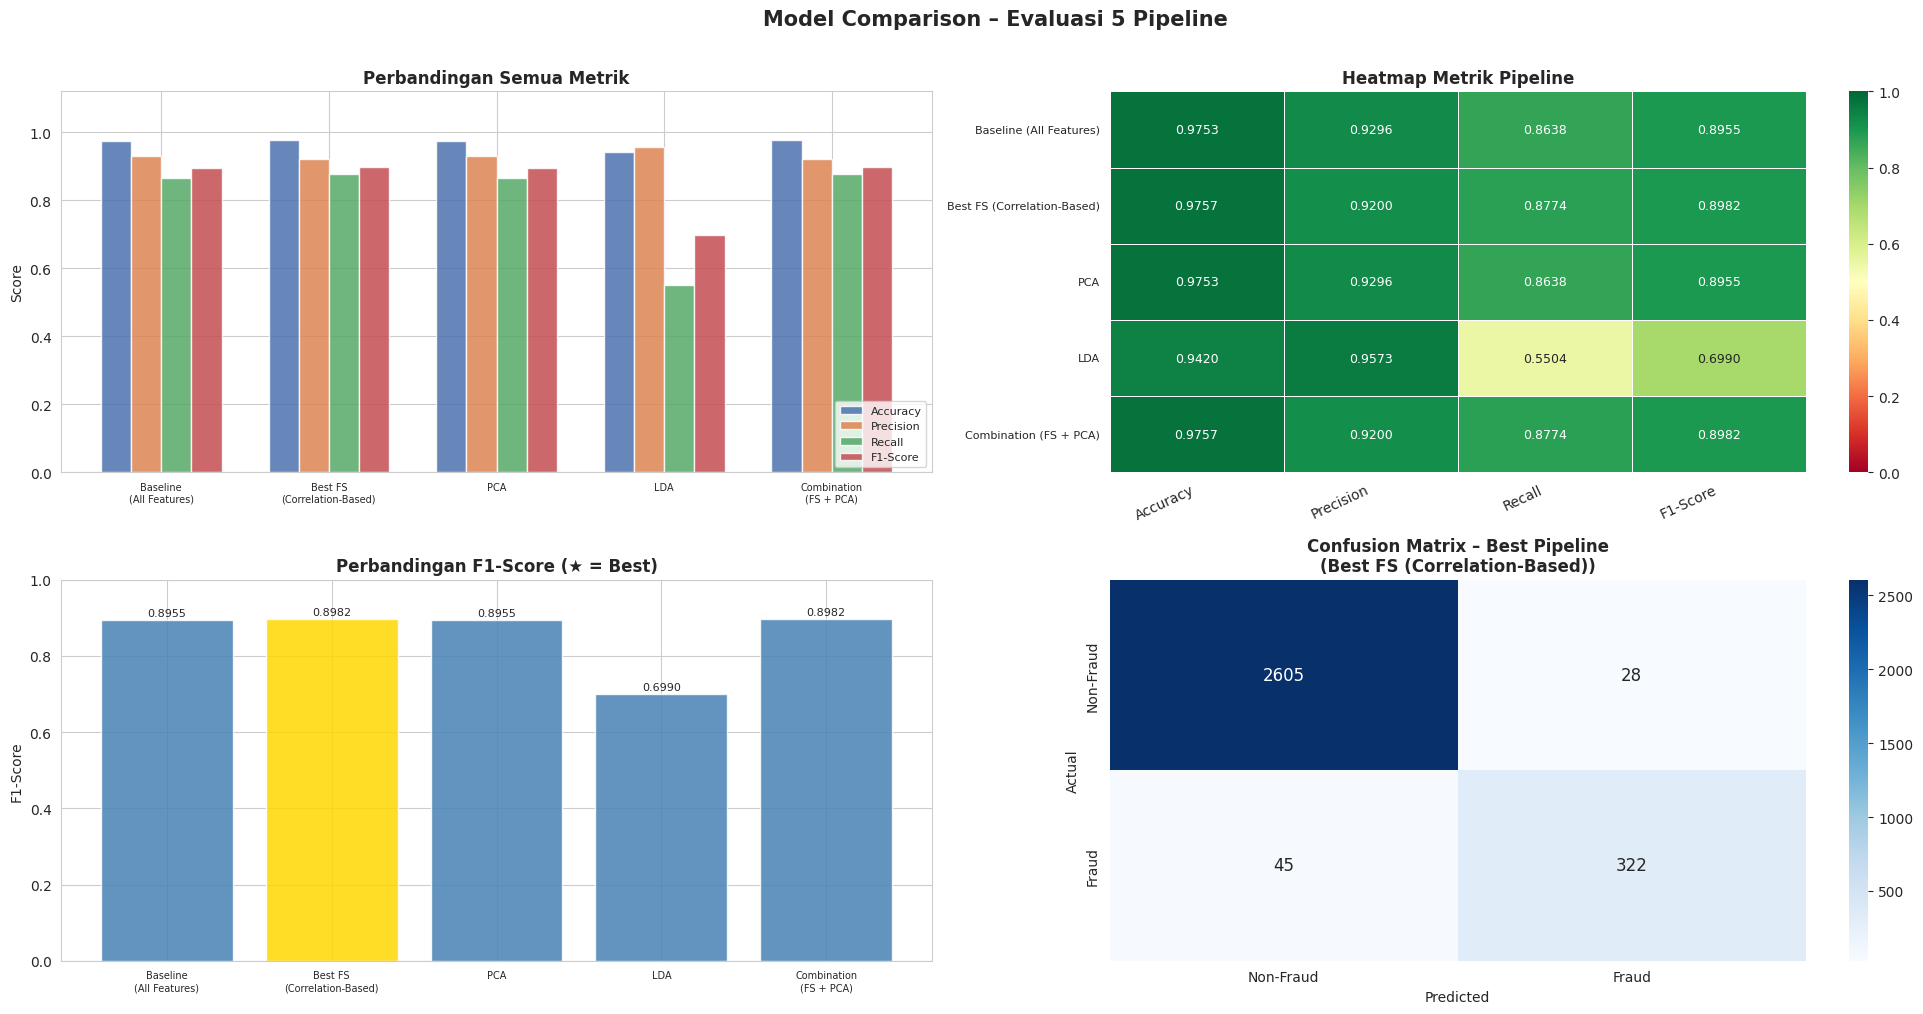


★  Pipeline terbaik  : Best FS (Correlation-Based)
   Accuracy  = 0.9757
   Precision = 0.9200
   Recall    = 0.8774
   F1-Score  = 0.8982


In [16]:
best_pipe = df_results['F1-Score'].idxmax()

fig = plt.figure(figsize=(20, 10))
fig.suptitle('Model Comparison – Evaluasi 5 Pipeline', fontsize=15, fontweight='bold', y=1.01)

# 1. Grouped bar chart
ax1 = fig.add_subplot(2, 2, 1)
n_pipelines = len(df_results)
n_metrics   = 4
metric_cols = ['Accuracy','Precision','Recall','F1-Score']
x    = np.arange(n_pipelines)
w    = 0.18
colors_m = ['#4C72B0','#DD8452','#55A868','#C44E52']

for j, (metric, color) in enumerate(zip(metric_cols, colors_m)):
    offset = (j - n_metrics/2 + 0.5) * w
    bars = ax1.bar(x + offset, df_results[metric].values, w,
                   label=metric, color=color, alpha=0.85, edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels([n.replace(' (', '\n(') for n in df_results.index],
                    fontsize=7, ha='center')
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.12)
ax1.set_title('Perbandingan Semua Metrik', fontweight='bold')
ax1.legend(loc='lower right', fontsize=8)

# 2. Heatmap
ax2 = fig.add_subplot(2, 2, 2)
sns.heatmap(df_results.astype(float), annot=True, fmt='.4f', cmap='RdYlGn',
            ax=ax2, linewidths=0.5, vmin=0, vmax=1, annot_kws={'size': 9})
ax2.set_title('Heatmap Metrik Pipeline', fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=25, ha='right')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=8)

# 3. F1 comparison
ax3 = fig.add_subplot(2, 2, 3)
f1s    = df_results['F1-Score']
colors_bar = ['gold' if n == best_pipe else 'steelblue' for n in f1s.index]
bars   = ax3.bar(range(len(f1s)), f1s.values, color=colors_bar, alpha=0.85, edgecolor='white')
ax3.set_xticks(range(len(f1s)))
ax3.set_xticklabels([n.replace(' (', '\n(') for n in f1s.index], fontsize=7)
ax3.set_ylabel('F1-Score')
ax3.set_title('Perbandingan F1-Score (★ = Best)', fontweight='bold')
ax3.set_ylim(0, 1.0)
for bar, val in zip(bars, f1s.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# 4. Best pipeline confusion matrix
ax4 = fig.add_subplot(2, 2, 4)
cm = conf_matrices[best_pipe]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Non-Fraud','Fraud'],
            yticklabels=['Non-Fraud','Fraud'],
            annot_kws={'size': 12})
ax4.set_title(f'Confusion Matrix – Best Pipeline\n({best_pipe})', fontweight='bold')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\n★  Pipeline terbaik  : {best_pipe}')
print(f'   Accuracy  = {df_results.loc[best_pipe, "Accuracy"]:.4f}')
print(f'   Precision = {df_results.loc[best_pipe, "Precision"]:.4f}')
print(f'   Recall    = {df_results.loc[best_pipe, "Recall"]:.4f}')
print(f'   F1-Score  = {df_results.loc[best_pipe, "F1-Score"]:.4f}')


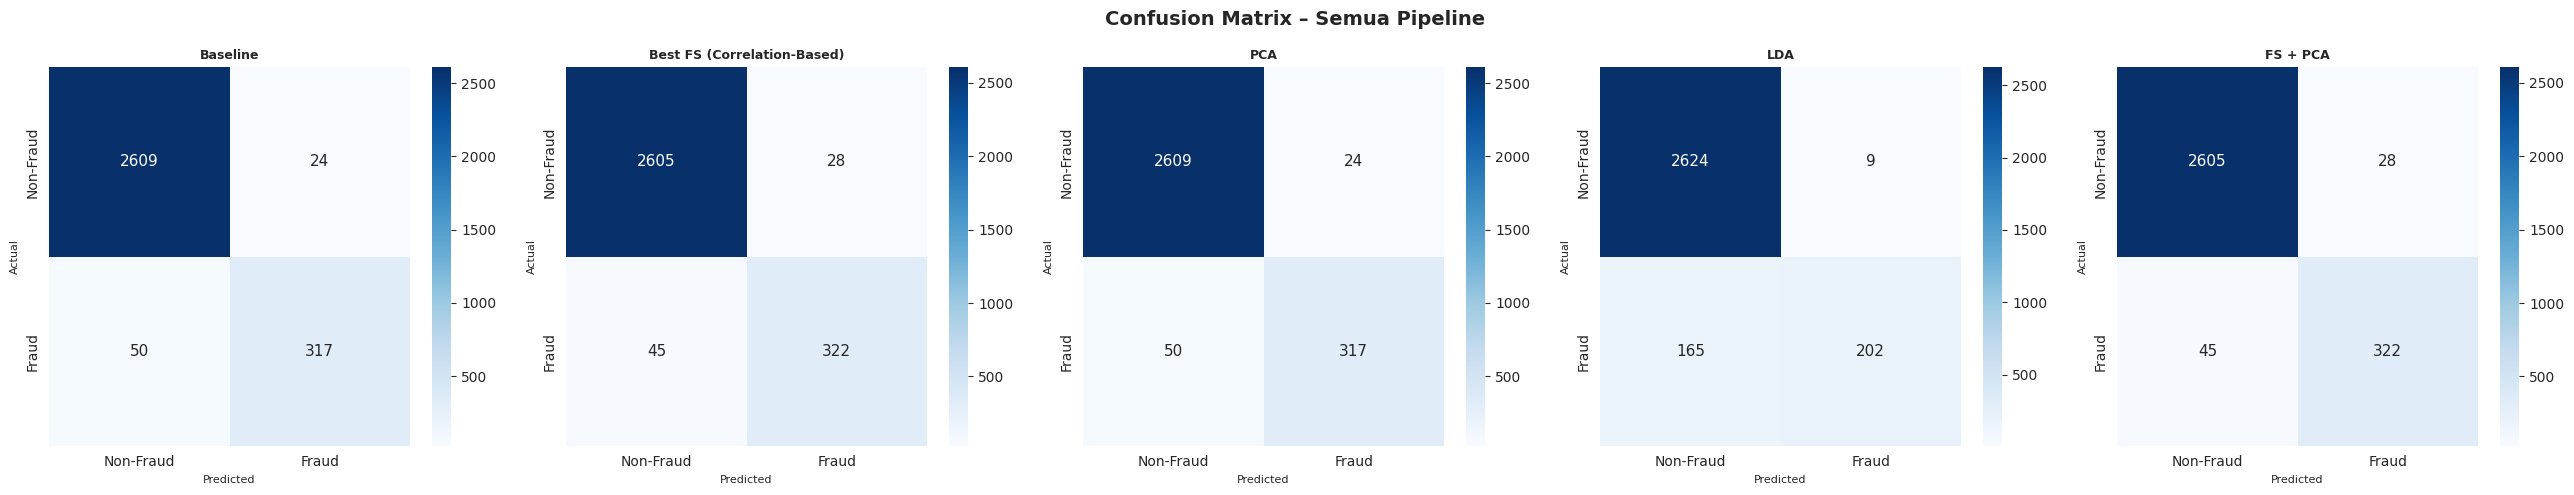

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
fig.suptitle('Confusion Matrix – Semua Pipeline', fontsize=14, fontweight='bold')

for ax, (name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Fraud','Fraud'],
                yticklabels=['Non-Fraud','Fraud'],
                annot_kws={'size': 11})
    short = (name
             .replace('Baseline (All Features)', 'Baseline')
             .replace('Best FS', 'Best FS')
             .replace('Combination (FS + PCA)', 'FS + PCA'))
    ax.set_title(short, fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)

plt.tight_layout()
plt.savefig('all_confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()


---
## Kesimpulan

### Section 1 – Feature Selection
| Metode | Kelebihan | Kekurangan |
|--------|-----------|------------|
| Correlation-Based | Cepat, mudah diinterpretasi | Hanya linear, tidak mempertimbangkan interaksi fitur |
| Backward Elimination | Berbasis statistik (p-value), objektif | Lebih lambat, sensitif terhadap multikolinearitas |

### Section 2 – Dimensionality Reduction
| Metode | Kelebihan | Kekurangan |
|--------|-----------|------------|
| PCA | Cepat, dapat digunakan untuk pipeline ML, interpretabel | Hanya menangkap hubungan linear |
| t-SNE | Mempertahankan struktur lokal, visualisasi kluster baik | Lambat, tidak deterministik, hanya untuk visualisasi |

### Section 3 – Model Comparison
Pipeline dievaluasi menggunakan **Accuracy, Precision, Recall, F1-Score**, dan **Confusion Matrix**.
Pipeline terbaik dipilih berdasarkan **F1-Score** karena dataset tidak seimbang (imbalanced).
